# Non-U.S. Launch Facility Coordinates for NOAA Station Search

The original EDA notebook narrowed NOAA planning to U.S. facilities because the first weather pull used U.S. ZIP codes. This notebook keeps the same idea of reducing messy launch-location strings to a smaller facility key, but applies it to every non-U.S. launch facility in the raw location table.

The main output is a facility-level reference table with:
- canonical non-U.S. launch facility name
- country and country code
- launch count and date range
- latitude and longitude for station searching
- raw launch-location strings that were condensed into each facility

Use the exported `data/derived/non_us_noaa_station_search_reference.csv` as the starting point for NOAA station searches by latitude/longitude.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("data")
OUTPUT_DIR = DATA_DIR / "derived"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

## Load Launch and Location Data

`Locations.csv` already includes several geographic levels. The fields used here are:
- `Orig_Addr`: raw launch-location string used by `Launches.csv`
- `Launch Site`: site-level label from the location reference
- `Comb Launch Site`: combined/canonical launch facility label
- `Lat` / `Lon`: pad or raw-location coordinates
- `Comb Launch Site Lat` / `Comb Launch Site Lon`: canonical facility coordinates

For station searching, the combined facility coordinates are the right first pass because NOAA station matching should happen once per facility, not once per pad string.

In [11]:
launches = pd.read_csv(DATA_DIR / "Launches.csv")
locations = pd.read_csv(DATA_DIR / "Locations.csv")

location_cols = [
    "Orig_Addr",
    "Country",
    "Country_Code",
    "Operator",
    "Launch Site",
    "Launch Site Lat",
    "Launch Site Lon",
    "Comb Launch Site",
    "Comb Launch Site Lat",
    "Comb Launch Site Lon",
    "Lat",
    "Lon",
]

launch_df = launches.merge(
    locations[location_cols],
    left_on="Location",
    right_on="Orig_Addr",
    how="left",
)

launch_df["launch_time_utc"] = pd.to_datetime(launch_df["Launch Time"], utc=True, errors="coerce")
launch_df["launch_date"] = launch_df["launch_time_utc"].dt.date
launch_df["Country_Code"] = launch_df["Country_Code"].astype("string").str.upper()

join_summary = pd.DataFrame(
    {
        "metric": [
            "total launches",
            "launches with location join",
            "launches missing location join",
            "unique raw location strings",
            "unique combined launch sites",
            "unique countries",
        ],
        "value": [
            len(launch_df),
            int(launch_df["Orig_Addr"].notna().sum()),
            int(launch_df["Orig_Addr"].isna().sum()),
            int(launch_df["Location"].nunique()),
            int(launch_df["Comb Launch Site"].nunique()),
            int(launch_df["Country"].nunique()),
        ],
    }
)

join_summary

,metric,value
0,total launches,6168
1,launches with location join,6168
2,launches missing location join,0
3,unique raw location strings,137
4,unique combined launch sites,39
5,unique countries,19


## Build the Non-U.S. Scope

This cell removes U.S. launches and keeps launches from other countries. A couple of sea-launch/barge records have missing country metadata in the raw location table; those are retained as `Unknown` because they still have facility coordinates and may be useful for station-search triage.

In [12]:
non_us_launches = launch_df.loc[launch_df["Country_Code"].fillna("UNKNOWN") != "US"].copy()
non_us_launches["facility_group"] = non_us_launches["Comb Launch Site"].fillna(non_us_launches["Launch Site"])
non_us_launches["facility_country"] = non_us_launches["Country"].fillna("Unknown")
non_us_launches["facility_country_code"] = non_us_launches["Country_Code"].fillna("UNKNOWN")
non_us_launches["facility_lat"] = non_us_launches["Comb Launch Site Lat"]
non_us_launches["facility_lon"] = non_us_launches["Comb Launch Site Lon"]

non_us_scope_summary = pd.DataFrame(
    {
        "metric": [
            "non-U.S. launches",
            "non-U.S. countries plus unknown",
            "non-U.S. facility groups",
            "non-U.S. raw location strings",
            "facilities missing combined coordinates",
        ],
        "value": [
            len(non_us_launches),
            int(non_us_launches["facility_country"].nunique()),
            int(non_us_launches["facility_group"].nunique()),
            int(non_us_launches["Location"].nunique()),
            int(
                non_us_launches.groupby("facility_group")[
                    ["Comb Launch Site Lat", "Comb Launch Site Lon"]
                ]
                .first()
                .isna()
                .any(axis=1)
                .sum()
            ),
        ],
    }
)

non_us_scope_summary

,metric,value
0,non-U.S. launches,4384
1,non-U.S. countries plus unknown,19
2,non-U.S. facility groups,31
3,non-U.S. raw location strings,87
4,facilities missing combined coordinates,0


## Facility-Level Reference Table

This is the condensed non-U.S. equivalent of the U.S. `facility_group` table. Each row is one launch facility, with launch volume, date coverage, and canonical coordinates for NOAA station searching.

In [13]:
def join_unique(values: pd.Series) -> str:
    clean = sorted({str(v) for v in values.dropna().unique()})
    return " | ".join(clean)


facility_reference = (
    non_us_launches.groupby(
        [
            "facility_country",
            "facility_country_code",
            "facility_group",
            "Comb Launch Site Lat",
            "Comb Launch Site Lon",
        ],
        dropna=False,
    )
    .agg(
        launches=("Launch Id", "count"),
        raw_location_strings=("Location", "nunique"),
        launch_site_labels=("Launch Site", "nunique"),
        first_launch=("launch_date", "min"),
        last_launch=("launch_date", "max"),
        operators=("Operator", join_unique),
        raw_locations=("Location", join_unique),
    )
    .reset_index()
    .rename(
        columns={
            "Comb Launch Site Lat": "facility_lat",
            "Comb Launch Site Lon": "facility_lon",
        }
    )
    .sort_values(["launches", "facility_country", "facility_group"], ascending=[False, True, True])
    .reset_index(drop=True)
)

facility_reference["coord_source"] = "Locations.csv Comb Launch Site Lat/Lon"
facility_reference["lat_lon_for_noaa_search"] = facility_reference.apply(
    lambda row: f"{row['facility_lat']:.6f}, {row['facility_lon']:.6f}"
    if pd.notna(row["facility_lat"]) and pd.notna(row["facility_lon"])
    else pd.NA,
    axis=1,
)
facility_reference["noaa_cdo_search_url"] = "https://www.ncei.noaa.gov/cdo-web/search"

facility_reference[
    [
        "facility_group",
        "facility_country",
        "facility_country_code",
        "launches",
        "first_launch",
        "last_launch",
        "facility_lat",
        "facility_lon",
        "lat_lon_for_noaa_search",
        "raw_location_strings",
    ]
].head(40)

,facility_group,facility_country,facility_country_code,launches,first_launch,last_launch,facility_lat,facility_lon,lat_lon_for_noaa_search,raw_location_strings
0,Plesetsk Cosmodrome,Russia,RU,1648,1966-03-17,2021-12-27,62.926415,40.555239,"62.926415, 40.555239",11
1,Baikonur Cosmodrome,Kazakhstan,KZ,1525,1957-10-04,2021-12-27,45.964585,63.305243,"45.964585, 63.305243",21
2,Guiana SC,French Guiana,GF,311,1970-03-10,2021-12-25,5.201590,-52.728131,"5.201590, -52.728131",6
3,Xichang Satellite LC,China,CN,167,1984-01-29,2021-12-29,27.893551,102.250931,"27.893551, 102.250931",3
4,Jiuquan Satellite LC,China,CN,158,1970-04-24,2021-12-29,40.984524,100.208695,"40.984524, 100.208695",6
5,Taiyuan Satellite LC,China,CN,99,1988-09-06,2021-12-26,38.848577,111.607983,"38.848577, 111.607983",4
6,Kapustin Yar,Russia,RU,97,1961-10-27,1999-04-28,48.575267,45.766175,"48.575267, 45.766175",3
7,Tanegashima SC,Japan,JP,85,1975-09-09,2021-12-22,30.374865,130.957646,"30.374865, 130.957646",2
8,Satish Dhawan SC,India,IN,78,1979-08-10,2021-08-12,13.728419,80.229276,"13.728419, 80.229276",3
9,Uchinoura SC,Japan,JP,42,1966-09-26,2021-11-09,31.251267,131.076127,"31.251267, 131.076127",2


## Coordinate Quality Check

Some facilities contain multiple pads. This check compares pad/raw-location coordinates against the combined facility coordinate so you can see where the canonical point is a center-of-facility approximation rather than an exact pad coordinate.

In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))


coord_check = non_us_launches.dropna(
    subset=["Lat", "Lon", "Comb Launch Site Lat", "Comb Launch Site Lon"]
).copy()
coord_check["pad_to_facility_km"] = haversine_km(
    coord_check["Comb Launch Site Lat"],
    coord_check["Comb Launch Site Lon"],
    coord_check["Lat"],
    coord_check["Lon"],
)

facility_coord_spread = (
    coord_check.groupby(["facility_country", "facility_country_code", "facility_group"])
    .agg(
        launches=("Launch Id", "count"),
        raw_location_strings=("Location", "nunique"),
        max_pad_to_facility_km=("pad_to_facility_km", "max"),
        median_pad_to_facility_km=("pad_to_facility_km", "median"),
    )
    .reset_index()
    .sort_values("max_pad_to_facility_km", ascending=False)
)

facility_coord_spread.head(25)

,facility_country,facility_country_code,facility_group,launches,raw_location_strings,max_pad_to_facility_km,median_pad_to_facility_km
7,French Guiana,GF,Guiana SC,311,6,6.447937,6.216343
18,New Zealand,NZ,Māhia Peninsula,23,2,5.825381,5.825365
22,Russia,RU,Plesetsk Cosmodrome,1648,11,4.522328,1.004830
6,China,CN,Xichang Satellite LC,167,3,1.195534,0.597771
8,India,IN,Satish Dhawan SC,78,3,0.817487,0.817487
17,Marshall Islands,MH,Ronald Reagan BMDTS,9,2,0.012128,0.012128
2,Brazil,BR,Alcântara LC,3,1,0.000000,0.000000
5,China,CN,Wenchang Satellite LC,15,2,0.000000,0.000000
4,China,CN,Taiyuan Satellite LC,99,4,0.000000,0.000000
9,Iran,IR,Imam Khomeini Spaceport,13,1,0.000000,0.000000


## Highest-Priority NOAA Station Search Targets

Launch count is the main prioritization signal. These are the facilities where finding weather coverage would affect the largest number of non-U.S. launches.

In [15]:
priority_facilities = facility_reference.loc[facility_reference["launches"] >= 10].copy()

priority_facilities[
    [
        "facility_group",
        "facility_country",
        "launches",
        "first_launch",
        "last_launch",
        "facility_lat",
        "facility_lon",
        "lat_lon_for_noaa_search",
        "noaa_cdo_search_url",
    ]
].sort_values("launches", ascending=False)

,facility_group,facility_country,launches,first_launch,last_launch,facility_lat,facility_lon,lat_lon_for_noaa_search,noaa_cdo_search_url
0,Plesetsk Cosmodrome,Russia,1648,1966-03-17,2021-12-27,62.926415,40.555239,"62.926415, 40.555239",https://www.ncei.noaa.gov/cdo-web/search
1,Baikonur Cosmodrome,Kazakhstan,1525,1957-10-04,2021-12-27,45.964585,63.305243,"45.964585, 63.305243",https://www.ncei.noaa.gov/cdo-web/search
2,Guiana SC,French Guiana,311,1970-03-10,2021-12-25,5.201590,-52.728131,"5.201590, -52.728131",https://www.ncei.noaa.gov/cdo-web/search
3,Xichang Satellite LC,China,167,1984-01-29,2021-12-29,27.893551,102.250931,"27.893551, 102.250931",https://www.ncei.noaa.gov/cdo-web/search
4,Jiuquan Satellite LC,China,158,1970-04-24,2021-12-29,40.984524,100.208695,"40.984524, 100.208695",https://www.ncei.noaa.gov/cdo-web/search
5,Taiyuan Satellite LC,China,99,1988-09-06,2021-12-26,38.848577,111.607983,"38.848577, 111.607983",https://www.ncei.noaa.gov/cdo-web/search
6,Kapustin Yar,Russia,97,1961-10-27,1999-04-28,48.575267,45.766175,"48.575267, 45.766175",https://www.ncei.noaa.gov/cdo-web/search
7,Tanegashima SC,Japan,85,1975-09-09,2021-12-22,30.374865,130.957646,"30.374865, 130.957646",https://www.ncei.noaa.gov/cdo-web/search
8,Satish Dhawan SC,India,78,1979-08-10,2021-08-12,13.728419,80.229276,"13.728419, 80.229276",https://www.ncei.noaa.gov/cdo-web/search
9,Uchinoura SC,Japan,42,1966-09-26,2021-11-09,31.251267,131.076127,"31.251267, 131.076127",https://www.ncei.noaa.gov/cdo-web/search


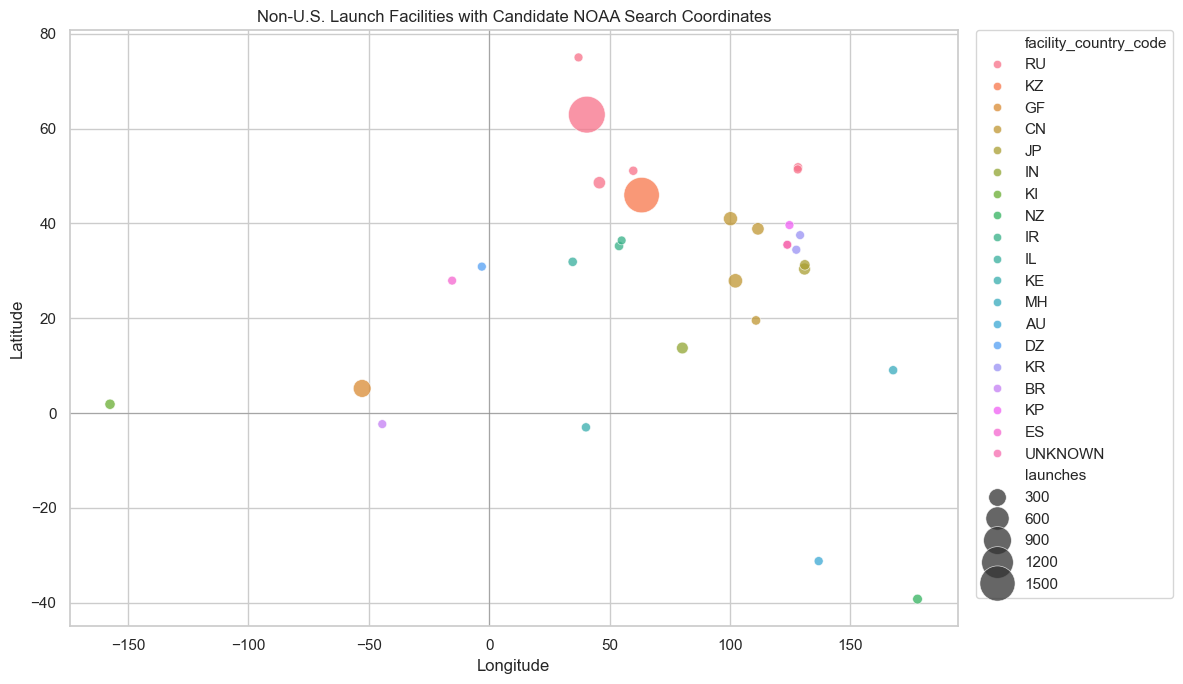

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = facility_reference.dropna(subset=["facility_lat", "facility_lon"]).copy()

sns.scatterplot(
    data=plot_df,
    x="facility_lon",
    y="facility_lat",
    size="launches",
    hue="facility_country_code",
    sizes=(40, 700),
    alpha=0.75,
    ax=ax,
)
ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.set_title("Non-U.S. Launch Facilities with Candidate NOAA Search Coordinates")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

## Raw Location to Facility Map

This table preserves the lower-level mapping from raw launch strings to the condensed facility group. Use it to audit how each facility row was formed.

In [17]:
raw_location_facility_map = (
    non_us_launches[
        [
            "Location",
            "facility_group",
            "facility_country",
            "facility_country_code",
            "Launch Site",
            "Lat",
            "Lon",
            "facility_lat",
            "facility_lon",
        ]
    ]
    .rename(
        columns={
            "Location": "raw_location",
            "Launch Site": "launch_site",
            "Lat": "raw_location_lat",
            "Lon": "raw_location_lon",
        }
    )
    .drop_duplicates()
    .sort_values(["facility_country", "facility_group", "raw_location"])
    .reset_index(drop=True)
)

raw_location_facility_map.head(80)

,raw_location,facility_group,facility_country,facility_country_code,launch_site,raw_location_lat,raw_location_lon,facility_lat,facility_lon
0,"Brigitte, Hammaguir, Algeria, France",Hammaguir,Algeria,DZ,Hammaguir,30.883284,-3.037591,30.883284,-3.037591
1,"LA-5B, RAAF Woomera Range Complex, Australia",RAAF Woomera RC,Australia,AU,RAAF Woomera RC,-31.198834,136.825066,-31.198834,136.825066
2,"VLS Pad, Alcântara Launch Center, Maranhão, Brazil",Alcântara LC,Brazil,BR,Alcântara LC,-2.315289,-44.370044,-2.315289,-44.370044
3,"Jiuquan Satellite Launch Center, China",Jiuquan Satellite LC,China,CN,Jiuquan Satellite LC,40.984524,100.208695,40.984524,100.208695
4,"Site 138 (LA-2B), Jiuquan Satellite Launch Center, China",Jiuquan Satellite LC,China,CN,Jiuquan Satellite LC,40.984524,100.208695,40.984524,100.208695
...,...,...,...,...,...,...,...,...,...
75,"Site 35/1, Plesetsk Cosmodrome, Russia",Plesetsk Cosmodrome,Russia,RU,Plesetsk Cosmodrome,62.927855,40.574841,62.926415,40.555239
76,"Site 41/1, Plesetsk Cosmodrome, Russia",Plesetsk Cosmodrome,Russia,RU,Plesetsk Cosmodrome,62.927855,40.574841,62.926415,40.555239
77,"Site 43/3, Plesetsk Cosmodrome, Russia",Plesetsk Cosmodrome,Russia,RU,Plesetsk Cosmodrome,62.919937,40.467031,62.926415,40.555239
78,"Site 43/4, Plesetsk Cosmodrome, Russia",Plesetsk Cosmodrome,Russia,RU,Plesetsk Cosmodrome,62.919937,40.467031,62.926415,40.555239


## Export NOAA Station Search References

The first CSV is the main facility-level NOAA search reference. The second CSV keeps the raw-location audit trail.

In [18]:
facility_export_cols = [
    "facility_group",
    "facility_country",
    "facility_country_code",
    "launches",
    "raw_location_strings",
    "launch_site_labels",
    "first_launch",
    "last_launch",
    "facility_lat",
    "facility_lon",
    "lat_lon_for_noaa_search",
    "coord_source",
    "noaa_cdo_search_url",
    "operators",
    "raw_locations",
]

facility_reference[facility_export_cols].to_csv(
    OUTPUT_DIR / "non_us_noaa_station_search_reference.csv",
    index=False,
)
raw_location_facility_map.to_csv(
    OUTPUT_DIR / "non_us_raw_location_facility_map.csv",
    index=False,
)
facility_coord_spread.to_csv(
    OUTPUT_DIR / "non_us_facility_coordinate_spread.csv",
    index=False,
)

pd.DataFrame(
    {
        "file": [
            str(OUTPUT_DIR / "non_us_noaa_station_search_reference.csv"),
            str(OUTPUT_DIR / "non_us_raw_location_facility_map.csv"),
            str(OUTPUT_DIR / "non_us_facility_coordinate_spread.csv"),
        ]
    }
)

,file
0,data\derived\non_us_noaa_station_search_reference.csv
1,data\derived\non_us_raw_location_facility_map.csv
2,data\derived\non_us_facility_coordinate_spread.csv


## Merge Plesetsk and Baikonur Launches to Weather

This section uses the same merge pattern as the U.S. weather workflow:
- clean the NOAA/LCD hourly weather file
- convert launch UTC timestamps to each facility's local standard time
- match each launch to the nearest weather observation within a 2-hour window
- summarize match coverage by facility

The timezone offsets below are fixed local-standard-time assumptions for the NOAA files:
- Plesetsk Cosmodrome: UTC+3
- Baikonur Cosmodrome: UTC+5

The date coverage in the downloaded files does not span every launch in the raw launch table, so the coverage table is the first output to check.

In [19]:
NON_US_WEATHER_FILE_MAP = {
    "Plesetsk Cosmodrome": {
        "rel_path": "plesetsk_cosmodrome/Plesetsk_Cosmodrome.csv",
        "utc_offset_hours": 3,
    },
    "Baikonur Cosmodrome": {
        "rel_path": "baikonur_cosmodrome/Baikonur_Cosmodrome.csv",
        "utc_offset_hours": 5,
    },
}

WEATHER_NUMERIC_COLUMNS = [
    "HourlyAltimeterSetting",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyStationPressure",
    "HourlySeaLevelPressure",
    "HourlyWetBulbTemperature",
    "HourlyWindSpeed",
    "HourlyWindGustSpeed",
    "HourlyWindDirection",
    "HourlyPressureChange",
    "HourlyPressureTendency",
]
WEATHER_TEXT_COLUMNS = [
    "HourlyPresentWeatherType",
    "HourlySkyConditions",
]
SHORT_DURATION_PRECIP_COLUMNS = [
    "ShortDurationPrecipitationValue005",
    "ShortDurationPrecipitationValue010",
    "ShortDurationPrecipitationValue015",
    "ShortDurationPrecipitationValue020",
    "ShortDurationPrecipitationValue030",
    "ShortDurationPrecipitationValue045",
    "ShortDurationPrecipitationValue060",
    "ShortDurationPrecipitationValue080",
    "ShortDurationPrecipitationValue100",
    "ShortDurationPrecipitationValue120",
    "ShortDurationPrecipitationValue150",
    "ShortDurationPrecipitationValue180",
]


def clean_lcd_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.extract(r"([-+]?[0-9]*\.?[0-9]+)")[0],
        errors="coerce",
    )


def load_best_hourly_weather(rel_path: str) -> pd.DataFrame:
    weather_raw = pd.read_csv(DATA_DIR / rel_path, low_memory=False)
    keep_cols = ["STATION", "DATE", "REPORT_TYPE"] + [
        c
        for c in WEATHER_NUMERIC_COLUMNS + WEATHER_TEXT_COLUMNS + SHORT_DURATION_PRECIP_COLUMNS
        if c in weather_raw.columns
    ]
    weather = weather_raw[keep_cols].copy()

    for col in [c for c in WEATHER_NUMERIC_COLUMNS + SHORT_DURATION_PRECIP_COLUMNS if c in weather.columns]:
        weather[col] = clean_lcd_numeric(weather[col])

    weather["weather_obs_time_lstd"] = pd.to_datetime(weather["DATE"], errors="coerce")
    weather = weather.dropna(subset=["weather_obs_time_lstd"]).copy()

    numeric_cols = [c for c in WEATHER_NUMERIC_COLUMNS if c in weather.columns]
    text_cols = [c for c in WEATHER_TEXT_COLUMNS if c in weather.columns]

    weather["hourly_nonnulls"] = weather[numeric_cols].notna().sum(axis=1) if numeric_cols else 0
    for col in text_cols:
        weather["hourly_nonnulls"] += weather[col].notna().astype(int)

    weather = (
        weather.loc[weather["hourly_nonnulls"] > 0]
        .sort_values(["weather_obs_time_lstd", "hourly_nonnulls"], ascending=[True, False])
        .drop_duplicates(subset=["weather_obs_time_lstd"], keep="first")
        .sort_values("weather_obs_time_lstd")
        .reset_index(drop=True)
    )

    present_weather = weather.get("HourlyPresentWeatherType", pd.Series("", index=weather.index)).fillna("").astype(str)
    sky_conditions = weather.get("HourlySkyConditions", pd.Series("", index=weather.index)).fillna("").astype(str)
    weather["present_weather_rain_flag"] = present_weather.str.contains(r"RA|DZ|SH", regex=True)
    weather["present_weather_fog_flag"] = present_weather.str.contains(r"FG|BR|HZ", regex=True)
    weather["present_weather_thunder_flag"] = present_weather.str.contains(r"TS", regex=True)
    weather["present_weather_snow_flag"] = present_weather.str.contains(r"SN|SG|IC|PL", regex=True)
    weather["cloud_cover_broken_or_overcast_flag"] = sky_conditions.str.contains(r"BKN|OVC", regex=True)

    available_short_duration_cols = [c for c in SHORT_DURATION_PRECIP_COLUMNS if c in weather.columns]
    weather["short_duration_precip_max"] = (
        weather[available_short_duration_cols].max(axis=1, skipna=True)
        if available_short_duration_cols
        else np.nan
    )

    return weather

In [20]:
weather_merges = []
weather_coverage_rows = []

for facility, config in NON_US_WEATHER_FILE_MAP.items():
    facility_launches = non_us_launches.loc[non_us_launches["facility_group"] == facility].copy()
    facility_launches = facility_launches.dropna(subset=["launch_time_utc"]).copy()
    facility_launches["launch_time_lstd"] = (
        facility_launches["launch_time_utc"] + pd.to_timedelta(config["utc_offset_hours"], unit="h")
    ).dt.tz_localize(None)
    facility_launches = facility_launches.sort_values("launch_time_lstd")

    weather = load_best_hourly_weather(config["rel_path"])

    merged = pd.merge_asof(
        facility_launches,
        weather,
        left_on="launch_time_lstd",
        right_on="weather_obs_time_lstd",
        direction="nearest",
        tolerance=pd.Timedelta("2h"),
    )
    merged["weather_matched"] = merged["weather_obs_time_lstd"].notna()
    merged["weather_time_diff_minutes"] = (
        (merged["launch_time_lstd"] - merged["weather_obs_time_lstd"]).dt.total_seconds().abs() / 60
    )
    merged["weather_file"] = config["rel_path"]
    merged["weather_utc_offset_hours"] = config["utc_offset_hours"]

    weather_coverage_rows.append(
        {
            "facility_group": facility,
            "launches": len(facility_launches),
            "matched_launches": int(merged["weather_matched"].sum()),
            "match_rate": merged["weather_matched"].mean(),
            "median_abs_diff_minutes": merged["weather_time_diff_minutes"].median(),
            "launch_start_utc": facility_launches["launch_time_utc"].min(),
            "launch_end_utc": facility_launches["launch_time_utc"].max(),
            "weather_start_lstd": weather["weather_obs_time_lstd"].min(),
            "weather_end_lstd": weather["weather_obs_time_lstd"].max(),
            "weather_rows_after_cleaning": len(weather),
            "weather_station_count": weather["STATION"].nunique() if "STATION" in weather.columns else np.nan,
        }
    )
    weather_merges.append(merged)

non_us_launch_weather = (
    pd.concat(weather_merges, ignore_index=True)
    .sort_values("launch_time_utc")
    .reset_index(drop=True)
)

non_us_launch_weather["launch_outcome_group"] = non_us_launch_weather["Launch Status"].where(
    non_us_launch_weather["Launch Status"] == "Success",
    "Not Success",
)
non_us_launch_weather["launch_success_binary"] = (non_us_launch_weather["Launch Status"] == "Success").astype(int)
non_us_launch_weather["launch_failure_binary"] = (non_us_launch_weather["Launch Status"] != "Success").astype(int)
non_us_launch_weather["launch_year"] = non_us_launch_weather["launch_time_utc"].dt.year
non_us_launch_weather["launch_decade"] = (non_us_launch_weather["launch_year"] // 10) * 10
non_us_launch_weather["launch_month"] = non_us_launch_weather["launch_time_utc"].dt.month
non_us_launch_weather["launch_hour_local"] = non_us_launch_weather["launch_time_lstd"].dt.hour

if "HourlyPrecipitation" in non_us_launch_weather.columns:
    non_us_launch_weather["precip_positive_flag"] = non_us_launch_weather["HourlyPrecipitation"].fillna(0).gt(0)
else:
    non_us_launch_weather["precip_positive_flag"] = False

non_us_launch_weather["weather_type_reported_flag"] = (
    non_us_launch_weather.get("HourlyPresentWeatherType", pd.Series("", index=non_us_launch_weather.index))
    .fillna("")
    .astype(str)
    .str.len()
    .gt(0)
)
non_us_launch_weather["high_wind_flag"] = non_us_launch_weather.get(
    "HourlyWindSpeed", pd.Series(np.nan, index=non_us_launch_weather.index)
).ge(15)
non_us_launch_weather["low_visibility_flag"] = non_us_launch_weather.get(
    "HourlyVisibility", pd.Series(np.nan, index=non_us_launch_weather.index)
).le(5)
non_us_launch_weather["high_humidity_flag"] = non_us_launch_weather.get(
    "HourlyRelativeHumidity", pd.Series(np.nan, index=non_us_launch_weather.index)
).ge(80)
non_us_launch_weather["dewpoint_depression"] = (
    non_us_launch_weather.get("HourlyDryBulbTemperature", pd.Series(np.nan, index=non_us_launch_weather.index))
    - non_us_launch_weather.get("HourlyDewPointTemperature", pd.Series(np.nan, index=non_us_launch_weather.index))
)
non_us_launch_weather["weather_match_quality_bin"] = pd.cut(
    non_us_launch_weather["weather_time_diff_minutes"],
    bins=[0, 15, 30, 60, 120],
    labels=["0-15 min", "15-30 min", "30-60 min", "60-120 min"],
    include_lowest=True,
)

non_us_weather_merge_coverage = (
    pd.DataFrame(weather_coverage_rows)
    .sort_values("matched_launches", ascending=False)
    .reset_index(drop=True)
)

non_us_weather_merge_coverage

,facility_group,launches,matched_launches,match_rate,median_abs_diff_minutes,launch_start_utc,launch_end_utc,weather_start_lstd,weather_end_lstd,weather_rows_after_cleaning,weather_station_count
0,Plesetsk Cosmodrome,1648,1091,0.662015,45.0,1966-03-17 10:28:00+00:00,2021-12-27 19:00:00+00:00,1966-01-01 00:00:00,1988-10-08 15:00:00,57732,1
1,Baikonur Cosmodrome,1525,145,0.095082,50.0,1957-10-04 19:28:00+00:00,2021-12-27 13:10:00+00:00,1966-01-01 02:00:00,1991-12-21 02:00:00,13176,1


In [ ]:
matched_non_us_launch_weather = non_us_launch_weather.loc[non_us_launch_weather["weather_matched"]].copy()
weather_feature_cols = [facility_group
    c
    for c in WEATHER_NUMERIC_COLUMNS
    + [
        "present_weather_rain_flag",
        "present_weather_fog_flag",
        "present_weather_thunder_flag",
        "present_weather_snow_flag",
        "cloud_cover_broken_or_overcast_flag",
        "short_duration_precip_max",
    ]
    if c in matched_non_us_launch_weather.columns
]

non_us_weather_feature_availability = pd.DataFrame(
    [
        {
            "feature": col,
            "matched_non_null_share": matched_non_us_launch_weather[col].notna().mean(),
            "matched_non_null_count": int(matched_non_us_launch_weather[col].notna().sum()),
        }
        for col in weather_feature_cols
    ]
).sort_values(["matched_non_null_share", "matched_non_null_count"], ascending=[False, False])

non_us_facility_weather_feature_availability = (
    matched_non_us_launch_weather.groupby("facility_group")[weather_feature_cols]
    .agg(lambda s: s.notna().mean())
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

non_us_weather_feature_availability

,feature,matched_non_null_share,matched_non_null_count
11,present_weather_rain_flag,1.000000,1236
12,present_weather_fog_flag,1.000000,1236
13,present_weather_thunder_flag,1.000000,1236
14,present_weather_snow_flag,1.000000,1236
15,cloud_cover_broken_or_overcast_flag,1.000000,1236
5,HourlySeaLevelPressure,0.988673,1222
3,HourlyVisibility,0.881068,1089
7,HourlyWindSpeed,0.875405,1082
0,HourlyDryBulbTemperature,0.873786,1080
9,HourlyPressureChange,0.872168,1078


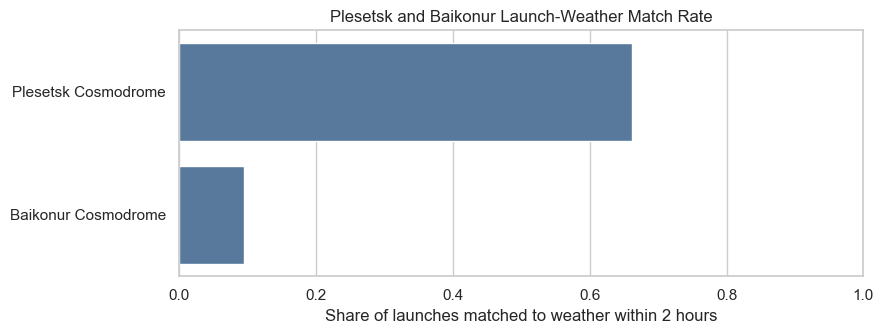

In [22]:
fig, ax = plt.subplots(figsize=(9, 3.5))
plot_df = non_us_weather_merge_coverage.sort_values("match_rate", ascending=False)
sns.barplot(data=plot_df, x="match_rate", y="facility_group", ax=ax, color="#4c78a8")
ax.set_title("Plesetsk and Baikonur Launch-Weather Match Rate")
ax.set_xlabel("Share of launches matched to weather within 2 hours")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [23]:
non_us_launch_weather.to_csv(
    OUTPUT_DIR / "non_us_launch_weather_merged.csv",
    index=False,
)
non_us_weather_merge_coverage.to_csv(
    OUTPUT_DIR / "non_us_weather_merge_coverage.csv",
    index=False,
)
non_us_weather_feature_availability.to_csv(
    OUTPUT_DIR / "non_us_weather_feature_availability.csv",
    index=False,
)
non_us_facility_weather_feature_availability.to_csv(
    OUTPUT_DIR / "non_us_facility_weather_feature_availability.csv",
    index=False,
)

pd.DataFrame(
    {
        "file": [
            str(OUTPUT_DIR / "non_us_launch_weather_merged.csv"),
            str(OUTPUT_DIR / "non_us_weather_merge_coverage.csv"),
            str(OUTPUT_DIR / "non_us_weather_feature_availability.csv"),
            str(OUTPUT_DIR / "non_us_facility_weather_feature_availability.csv"),
        ]
    }
)

,file
0,data\derived\non_us_launch_weather_merged.csv
1,data\derived\non_us_weather_merge_coverage.csv
2,data\derived\non_us_weather_feature_availability.csv
3,data\derived\non_us_facility_weather_feature_availability.csv


## Bottom Line

The non-U.S. launch records can be reduced to one row per combined launch facility using the existing `Comb Launch Site` fields. The resulting facility coordinates give a practical latitude/longitude search key for NOAA station discovery.

With the current added weather files, Plesetsk and Baikonur can also be merged to launch events using local-standard-time nearest-neighbor matching. The merge coverage table should be reviewed before using these records for modeling because the downloaded weather files cover only part of each facility's full launch history, and Baikonur currently contains a much narrower weather feature set than Plesetsk.